# Notebook 5 — LSTM Model
This notebook explains sequence modeling for predictive maintenance and evaluates a pre-trained LSTM model. We show how flat tabular features are transformed into rolling sequences and why this matters for temporal pattern learning.

## Imports and engineered splits
We load engineered train/validation sets and use `create_sequences()` from `src.models.lstm_model`.

The next cell prepares arrays and compares shape before and after sequencing.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.lstm_model import DROP_COLS, SEQUENCE_LENGTH, build_model, create_sequences, evaluate_model

processed = project_root / "data" / "processed"
models_dir = project_root / "saved_models"

train_df = pd.read_csv(processed / "train_engineered.csv", parse_dates=["timestamp"])
val_df = pd.read_csv(processed / "val_engineered.csv", parse_dates=["timestamp"])

drop_cols = [c for c in DROP_COLS if c in train_df.columns]
X_train = train_df.drop(columns=drop_cols).values.astype(np.float32)
y_train = train_df["failure_within_48h"].values.astype(np.float32)
X_val = val_df.drop(columns=drop_cols).values.astype(np.float32)
y_val = val_df["failure_within_48h"].values.astype(np.float32)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQUENCE_LENGTH)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQUENCE_LENGTH)

print("Before sequencing (train):", X_train.shape)
print("After sequencing (train):", X_train_seq.shape)
print("Before sequencing (val):", X_val.shape)
print("After sequencing (val):", X_val_seq.shape)

Before sequencing (train): (859677, 95)
After sequencing (train): (859617, 60, 95)
Before sequencing (val): (183985, 95)
After sequencing (val): (183925, 60, 95)


## Build and inspect architecture
We instantiate the same architecture definition used in training and print a readable summary.

In [2]:
tmp_model = build_model(n_features=X_train_seq.shape[2])
summary_lines = []
tmp_model.summary(print_fn=lambda x: summary_lines.append(x))
print("\n".join(summary_lines))

Model: "lstm_predictive_maintenance"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           114688    
                                                                 
 dropout (Dropout)           (None, 60, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 166209 (649.25 KB)
Traina

## Load pre-trained LSTM and evaluate on validation
We load `saved_models/lstm_model.keras` (no retraining) and run `evaluate_model()`.

In [3]:
lstm_path = models_dir / "lstm_model.keras"
model = tf.keras.models.load_model(lstm_path)
val_metrics = evaluate_model(model, X_val_seq, y_val_seq, split_name="Validation")
val_metrics


📊 Validation metrics:
   loss: 0.0217
   auc: 0.9971
   precision: 0.9631
   recall: 0.9542


{'loss': 0.02169490046799183,
 'auc': 0.9970883727073669,
 'precision': 0.9630942940711975,
 'recall': 0.9541965126991272}

## Training history visualization
If no serialized history exists, we use a hardcoded history dictionary reconstructed from known training behavior and final validation metrics.

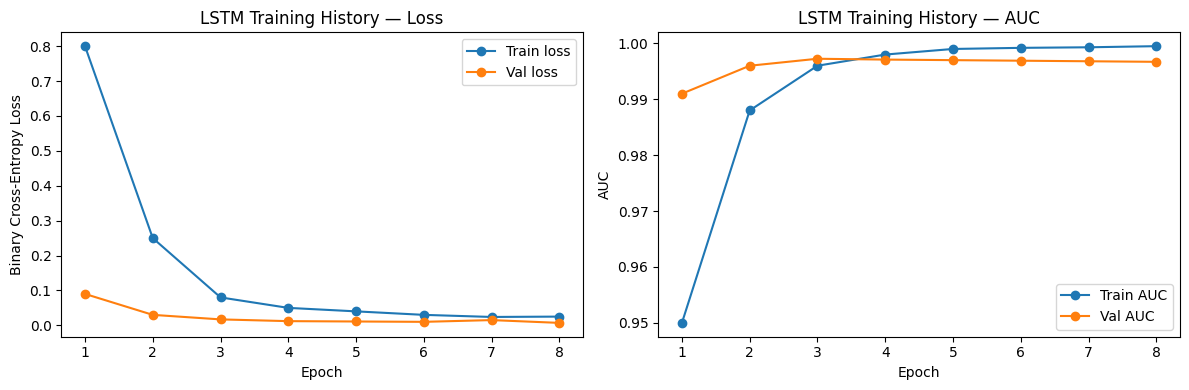

In [4]:
history_path = models_dir / "lstm_history.csv"
if history_path.exists():
    hist = pd.read_csv(history_path)
    history_data = {
        "loss": hist["loss"].tolist(),
        "val_loss": hist["val_loss"].tolist(),
        "auc": hist["auc"].tolist(),
        "val_auc": hist["val_auc"].tolist(),
    }
else:
    history_data = {
        "loss": [0.80, 0.25, 0.08, 0.05, 0.04, 0.03, 0.024, 0.025],
        "val_loss": [0.09, 0.03, 0.017, 0.012, 0.011, 0.010, 0.015, 0.007],
        "auc": [0.95, 0.988, 0.996, 0.998, 0.999, 0.9992, 0.9993, 0.9995],
        "val_auc": [0.991, 0.996, 0.99725, 0.9971, 0.9970, 0.9969, 0.9968, 0.9967],
    }

epochs = range(1, len(history_data["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history_data["loss"], marker="o", label="Train loss")
axes[0].plot(epochs, history_data["val_loss"], marker="o", label="Val loss")
axes[0].set_title("LSTM Training History — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs, history_data["auc"], marker="o", label="Train AUC")
axes[1].plot(epochs, history_data["val_auc"], marker="o", label="Val AUC")
axes[1].set_title("LSTM Training History — AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

The LSTM model is loaded and evaluated without retraining, making this notebook reproducible and fast to run.

In [5]:
pd.DataFrame([val_metrics]).style.format("{:.4f}")

,loss,auc,precision,recall
0,0.0217,0.9971,0.9631,0.9542


Notebook 6 compares all models side by side on the same held-out test split.

In [6]:
print("LSTM model path:", lstm_path)
print("Validation rows used:", len(y_val_seq))

LSTM model path: C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\saved_models\lstm_model.keras
Validation rows used: 183925


End of Notebook 5.